### Question 1
Create a Python script that generates two arrays: one representing the number of hours you spend on Instagram each day for a week, and the other representing your daily phone battery percentage at the end of the day. Plot these as a scatter plot using matplotlib.

Two NumPy arrays represent 7 days of tracking: `instagram_hours` (independent variable $X$) recording daily active screen time, and `battery_percentage` (dependent variable $y$) recording remaining phone battery at the end of the day. The scatter plot visualizes the negative correlation between usage duration and remaining battery power.

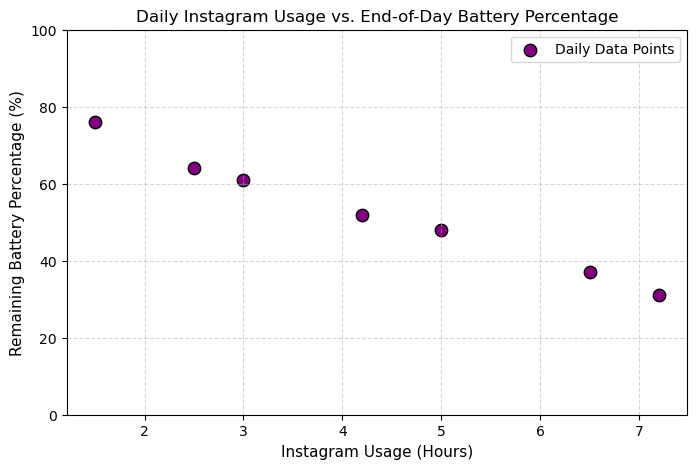

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Daily Instagram screen time (hours/day for 7 days)
instagram_hours = np.array([1.5, 2.5, 3.0, 4.2, 5.0, 6.5, 7.2])

# 2. End-of-day battery percentage remaining (out of 100%)
battery_percentage = np.array([76.0, 64.0, 61.0, 52.0, 48.0, 37.0, 31.0])

# 3. Scatter plot visualization
plt.figure(figsize=(8, 5))
plt.scatter(instagram_hours, battery_percentage, color='purple', s=80, edgecolors='black', label='Daily Data Points')
plt.title('Daily Instagram Usage vs. End-of-Day Battery Percentage', fontsize=12)
plt.xlabel('Instagram Usage (Hours)', fontsize=11)
plt.ylabel('Remaining Battery Percentage (%)', fontsize=11)
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Question 2
Using scikit-learn's LinearRegression, fit a simple linear regression model to predict daily battery percentage based on Instagram usage hours from your generated data. Print the model's slope (coefficient) and intercept.

Fitting a `LinearRegression` model computes the best-fit line parameters for the linear equation $\hat{y} = mx + c$. The negative slope ($m = \text{coef\_}$) reflects the rate of battery drain per additional hour on Instagram, while the intercept ($c = \text{intercept\_}$) estimates the remaining battery percentage assuming zero hours spent on the app.

In [2]:
from sklearn.linear_model import LinearRegression

# Reshape X to 2D array as required by scikit-learn (n_samples, n_features)
X = instagram_hours.reshape(-1, 1)
y = battery_percentage

# Instantiate and fit the Linear Regression model
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Model Slope (Coefficient): {slope:.3f} (% battery drain per hour)")
print(f"Model Intercept:           {intercept:.3f} (% battery expected at 0 hours)")
print(f"\nRegression Formula: Battery % = {slope:.3f} * (Instagram Hours) + {intercept:.3f}")

Model Slope (Coefficient): -7.432 (% battery drain per hour)
Model Intercept:           84.460 (% battery expected at 0 hours)

Regression Formula: Battery % = -7.432 * (Instagram Hours) + 84.460


### Question 3
Plot the regression line on top of your scatter plot to visualize the relationship between Instagram hours and battery percentage using matplotlib.

*(Hint: Use model.predict() to get the predicted values for your x-axis data and plot them as a line.)*

Overlaying `model.predict(X)` onto the scatter plot verifies that the linear estimator captures the downward trend between continuous social media screen time and daily phone battery life.

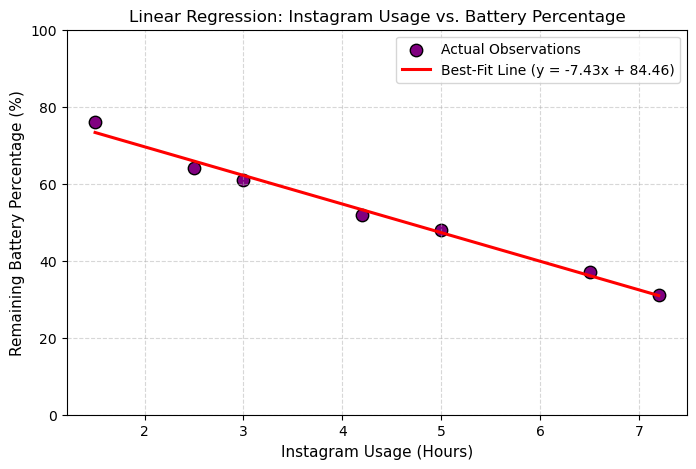

In [3]:
# Generate predictions for the regression line
y_pred = model.predict(X)

plt.figure(figsize=(8, 5))
# Actual observation points
plt.scatter(instagram_hours, battery_percentage, color='purple', s=80, edgecolors='black', label='Actual Observations')
# Best-fit regression line
plt.plot(instagram_hours, y_pred, color='red', linewidth=2.2, label=f'Best-Fit Line (y = {slope:.2f}x + {intercept:.2f})')

plt.title('Linear Regression: Instagram Usage vs. Battery Percentage', fontsize=12)
plt.xlabel('Instagram Usage (Hours)', fontsize=11)
plt.ylabel('Remaining Battery Percentage (%)', fontsize=11)
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Question 4
Calculate the mean squared error (MSE) between your actual battery percentages and the predicted values from your regression model using sklearn.metrics.mean_squared_error. Print the MSE value and explain in one line what a lower MSE indicates.

The Mean Squared Error evaluates model accuracy by calculating the average squared deviation between actual values ($y_i$) and fitted predictions ($\hat{y}_i$):
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
A lower MSE indicates that the model's predicted values are closer to the actual data points, signifying higher prediction accuracy and a better fit to the dataset.

In [4]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error
mse_value = mean_squared_error(battery_percentage, y_pred)
rmse_value = np.sqrt(mse_value)

print(f"Mean Squared Error (MSE):       {mse_value:.3f}")
print(f"Root Mean Squared Error (RMSE):  {rmse_value:.3f} %")
print("\nInterpretation: A lower MSE indicates that the model's predicted values are closer to the actual data points, signifying higher prediction accuracy and a better fit to the dataset.")

Mean Squared Error (MSE):       2.125
Root Mean Squared Error (RMSE):  1.458 %

Interpretation: A lower MSE indicates that the model's predicted values are closer to the actual data points, signifying higher prediction accuracy and a better fit to the dataset.
